In [ ]:
#Exploaratory Data Analysis

In [1]:
import os
print(os.cpu_count())

8


In [2]:
import psutil
print(psutil.virtual_memory())

svmem(total=8345964544, available=1477341184, percent=82.3, used=6868623360, free=1477341184)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r"\\wsl.localhost\Ubuntu\home\hemasree\bugs_severity_classification\data\raw\bugs.csv")
df.head()

,id,summary,raw_severity,severity,priority,product,component,status,resolution,creation_time,comment_count,summary_len,summary_word_count,scraped_at
0,84106,[FIX]Not correctly retrieving post data when s...,critical,critical,P2,Firefox,File Handling,RESOLVED,FIXED,2001-06-05T06:28:26Z,41,94,16,2026-04-18T07:15:36.959507+00:00
1,125234,"add an alert to ""save page as"" dialog",critical,critical,--,Firefox,File Handling,RESOLVED,INCOMPLETE,2002-02-13T13:59:33Z,18,37,8,2026-04-18T07:15:36.959507+00:00
2,167104,Back/Forward buttons and context options alway...,critical,critical,--,Firefox,General,VERIFIED,WORKSFORME,2002-09-06T15:48:57Z,4,57,7,2026-04-18T07:15:36.959507+00:00
3,170521,Incorrectly renders various web pages,critical,critical,--,Firefox,General,VERIFIED,DUPLICATE,2002-09-24T15:52:06Z,4,37,5,2026-04-18T07:15:36.959507+00:00
4,170768,Phoenix refuses to start due missing libstdc++...,critical,critical,--,Firefox,General,VERIFIED,INVALID,2002-09-25T17:34:43Z,7,61,7,2026-04-18T07:15:36.959507+00:00


In [9]:
df.columns

Index(['id', 'summary', 'raw_severity', 'severity', 'priority', 'product',
       'component', 'status', 'resolution', 'creation_time', 'comment_count',
       'summary_len', 'summary_word_count', 'scraped_at'],
      dtype='object')

In [11]:
#check for null values
df.isnull().sum()

id                    0
summary               0
raw_severity          0
severity              0
priority              0
product               0
component             0
status                0
resolution            0
creation_time         0
comment_count         0
summary_len           0
summary_word_count    0
scraped_at            0
dtype: int64

In [14]:
# Count of bugs per severity
severity_counts = df['raw_severity'].value_counts()

Text(0.5, 1.0, 'Distribution of Bug Severities')

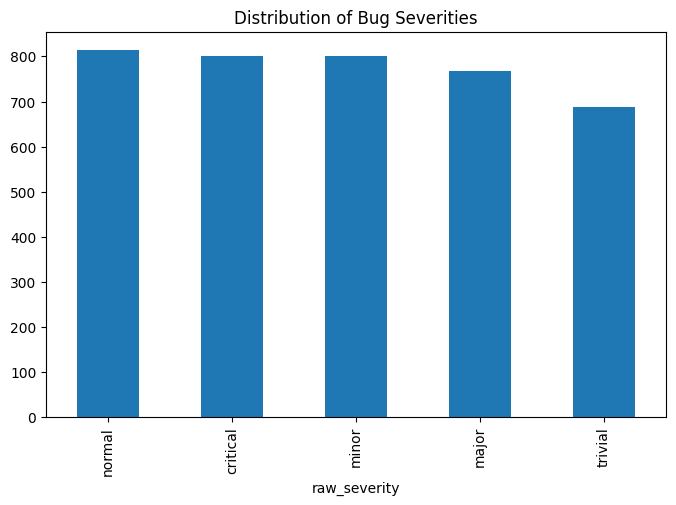

In [15]:
# plotting the severity distribution
plt.figure(figsize=(8, 5))
severity_counts.plot(kind='bar')
plt.title('Distribution of Bug Severities')

In [16]:
df["summary_word_count"].describe()

count    3872.000000
mean        8.580579
std         3.957500
min         1.000000
25%         6.000000
50%         8.000000
75%        11.000000
max        43.000000
Name: summary_word_count, dtype: float64

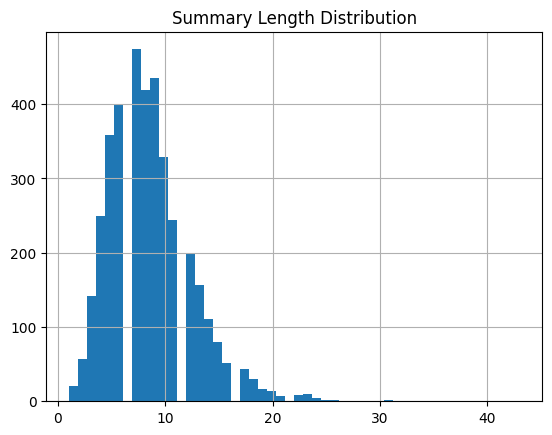

In [17]:
df["summary_word_count"].hist(bins=50)
plt.title("Summary Length Distribution")
plt.show()

In [18]:
pd.crosstab(df["component"], df["severity"])

severity,critical,high,low,medium
component,,,,
Accessibility Tools,0,2,5,0
Add-ons Manager,26,34,70,0
Address Bar,26,5,17,1
Application Update,2,0,20,0
Autocomplete,0,0,3,0
...,...,...,...,...
XML,2,0,4,0
XPCOM,10,2,9,2
XPConnect,0,0,1,0


In [19]:
pd.crosstab(df["product"], df["severity"])

severity,critical,high,low,medium
product,,,,
Core,200,200,400,200
DevTools,200,168,288,200
Firefox,200,200,400,200
Firefox for Android,2,0,0,14
Toolkit,200,200,400,200
